In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# Loading the dataset

Combining the datasets

In [2]:
reddit_df = pd.read_csv("reddit_data.csv")
local_df = pd.read_excel("Phase2_Local.xlsx")
global_df = pd.read_excel("Phase2_Global.xlsx")

In [3]:
# Make all column names lowercase + clean
def clean_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

reddit_df = clean_cols(reddit_df)
local_df = clean_cols(local_df)
global_df = clean_cols(global_df)

In [4]:
common_cols = list(
    set(local_df.columns) & set(global_df.columns)
)

local_df = local_df[common_cols]
global_df = global_df[common_cols]

In [5]:
combined_df = pd.concat(
    [local_df, global_df, reddit_df],
    ignore_index=True
)

In [6]:
combined_df

,philippine_context?,source_subreddit,post_url,upvotes_/_score,theme_tag,intern_notes,post_or_comment,notable_quote,date_posted,content_(full_text),platform_mentioned,post_title
0,Yes,r/phcareers,https://www.reddit.com/r/phcareers/comments/1n...,1263,UX,NaN,post,"Yes, totoo, ako nga na merong 19-years of expe...",2025-09,Madami akong nababasa dito about difficulty of...,LinkedIn,Use of LinkedIN Connections to Secure Unposted...
1,Yes,r/phcareers,https://www.reddit.com/r/phcareers/comments/1l...,401,PROCESS,NaN,post,"Nagparegular lang ako, then I am now rendering...",2025-06,"M \[28\] and an engineer, this July I will be ...",NaN,"Nasabihan ako ng ""Lipat ka kasi ng lipat ng ku..."
2,Yes,r/phcareers,https://www.reddit.com/r/phcareers/comments/1l...,284,UX,NaN,post,I have long known that graduating from a prest...,2025-07,I am a first-time job seeker and my experience...,NaN,Job hunting is draining and demoralizing
3,Yes,r/phcareers,https://www.reddit.com/r/phcareers/comments/1p...,272,GHOSTING,NaN,post,"Napaisip pa ako, “Pag ito hindi ako tinanggap,...",2025-12,"Hi, guys! 👋🏼 December is almost ending and I j...",NaN,Hired before I ended the year!
4,Yes,r/phcareers,https://www.reddit.com/r/phcareers/comments/1m...,262,GHOSTING,NaN,post,I don’t have much luck landing in a VA role an...,2025-08,I’m a recent graduate of Psychology and only r...,NaN,Regret as a fresh graduate kung kelan may degr...
...,...,...,...,...,...,...,...,...,...,...,...,...
334,Yes,phcareers,https://www.reddit.com/r/phcareers/comments/1d...,3,EMOTIONAL,Expresses frustration from repeated effort wit...,comment,"""It sucks to be eager and getting nothing.""",24-Jun,"I feel you deeply OP, since March, I'm still t...",NaN,My goal was to have a new job by June. This Ju...
335,Yes,phcareers,https://www.reddit.com/r/phcareers/comments/1d...,3,VISIBILITY,Highlights lack of responses despite multiple ...,comment,"""I applied 24 applications for web development...",24-Jun,Hello OP. I feel you. when I was a fresh gradu...,NaN,My goal was to have a new job by June. This Ju...
336,Yes,phcareers,https://www.reddit.com/r/phcareers/comments/1d...,3,GHOSTING,"Shows ghosting despite strong qualifications, ...",comment,"""Pero gino-ghost pa rin ako ng recruiters and ...",24-Jun,"OP, if it is any consolation, I am also in the...",NaN,My goal was to have a new job by June. This Ju...
337,Yes,phcareers,https://www.reddit.com/r/phcareers/comments/1d...,3,GHOSTING,"Indicates ghosting after interviews, contribut...",comment,"""I've had some job interviews and some that I ...",24-Jun,I've been applying since Feb until now wala pa...,NaN,My goal was to have a new job by June. This Ju...


# Ensuring Quality Standards

In [7]:
len(combined_df)

339

339 entries

In [8]:
yes_count = (combined_df["philippine_context?"] == "Yes").sum()
total = len(combined_df)

percentage = (yes_count / total) * 100
print(f"{percentage:.2f}%")

64.60%


At least 30% of entries should are from Philippine-focused subreddits (r/Philippines, r/phcareers, r/OFW). 

In [9]:
combined_df["theme_tag"].value_counts()

theme_tag
PROCESS       72
UX            70
GHOSTING      61
EMOTIONAL     61
RELEVANCE     38
SCAM          17
OTHER         15
VISIBILITY     5
Name: count, dtype: int64

At least 5 different Theme Tags are represented

In [10]:
combined_df["source_subreddit"].dropna().unique()

array(['r/phcareers', 'r/Philippines', 'r/jobs', 'r/recruitinghell',
       'r/jobsearchhacks', 'r/careerguidance', 'phcareers'], dtype=object)

Entries span at least 3 different subbreddits (7 in this case)

# EDA

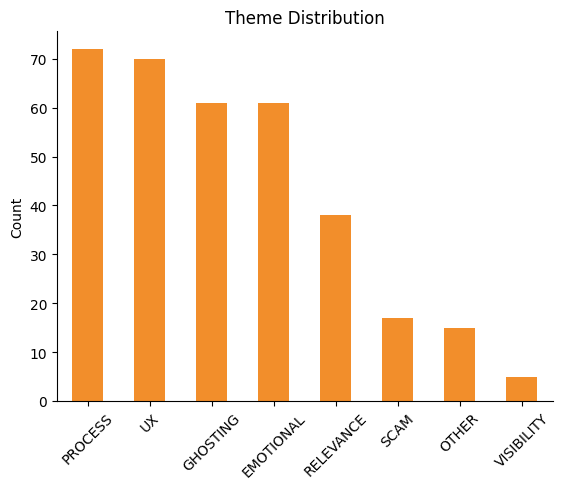

In [11]:
import matplotlib.pyplot as plt

theme_counts = combined_df["theme_tag"].value_counts()

plt.figure()
ax = theme_counts.plot(kind="bar", color="#F28E2B")

plt.title("Theme Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

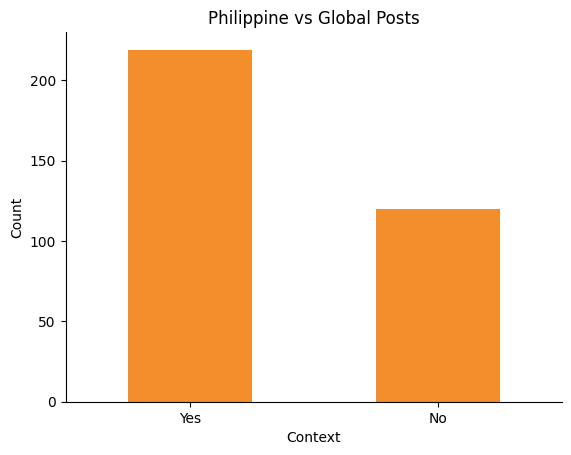

In [16]:
ph_counts = combined_df["philippine_context?"].value_counts()

plt.figure()
ax = ph_counts.plot(kind="bar", color="#F28E2B")

plt.title("Philippine vs Global Posts")
plt.xlabel("Context")
plt.ylabel("Count")
plt.xticks(rotation=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

# Advanced Methods

My plan here was to run K-means clusters on each theme tag and uncover what specific events were occurring. 

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## PROCESS

In [26]:
# filter PROCESS theme
process_df = combined_df[combined_df["theme_tag"] == "PROCESS"].copy()

texts = process_df["content_(full_text)"].fillna("").tolist()

# embeddings
embeddings = model.encode(texts, show_progress_bar=False)

# normalize (important)
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)

# clustering
from sklearn.cluster import KMeans
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings)

process_df["sub_cluster"] = labels

# print all contents per cluster
for i in range(k):
    print(f"\n===== PROCESS - Sub-cluster {i} =====\n")
    
    cluster_texts = process_df[process_df["sub_cluster"] == i]["content_(full_text)"]
    
    for idx, text in enumerate(cluster_texts):
        print(f"{idx+1}. {text}\n")


===== PROCESS - Sub-cluster 0 =====

1. *My POV comes from \~5 years of experience across different industries/fields but roughly operations, project management so please keep that in mind while reading*

  
Things I did differently this job hunt:

1. RESUME: Made only one CV type and selected experiences that fit for the role types I wanted (project/program/ops management). Removed all extracurriculars and internships, only kept school name and degree. By the way, I still stand by \~8-10% of your applications should make it past first stage for the current job market. I got replies from 2/\~24 applications.

2. USAGE OF AI: Be transparent with interviewers when you use AI for case studies and use it strategically. For my case study, I used it mostly as a design base (I hate making slides) AND also submitted a 'without AI' version/scratch paper. 

  
I also used AI for interview prep. I shared the job description, and my resume (anonymized) with AI and prompted it to draft 15 intervie

## UX

In [28]:
# filter PROCESS theme
process_df = combined_df[combined_df["theme_tag"] == "UX"].copy()

texts = process_df["content_(full_text)"].fillna("").tolist()

# embeddings
embeddings = model.encode(texts, show_progress_bar=False)

# normalize (important)
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)

# clustering
from sklearn.cluster import KMeans
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings)

process_df["sub_cluster"] = labels

# print all contents per cluster
for i in range(k):
    print(f"\n===== UX - Sub-cluster {i} =====\n")
    
    cluster_texts = process_df[process_df["sub_cluster"] == i]["content_(full_text)"]
    
    for idx, text in enumerate(cluster_texts):
        print(f"{idx+1}. {text}\n")


===== UX - Sub-cluster 0 =====

1. Madami akong nababasa dito about difficulty of securing a job these days.

Yes, totoo, ako nga na merong 19-years of experience sa IT industry [umabot ng 9-months](https://www.reddit.com/r/phcareers/comments/1lk6j2q/got_a_new_job_after_9months_of_search/) before I secured my current job that I'm in (cybersecurity tech writing role).

I posted it somewhere dito rin sa Reddit, but I think this method na tried and tested ko na for the last 4 jobs, I think it deserves its own thread dito sa PHCareers. I believe that it is highly underutilized by job seekers.

The reality ng buhay natin ngayon na connections &gt; skills pagdating sa workplace and our capability to secure jobs. This is because many jobs matutunan naman while on the job mismo. Mapapansin yan sa corporate setting, na sa dinami-dami ng applicants na na-interview yung inaanak ni boss din pala ang mahahire, kahit kulang na kulang sa skills.

So eto yun, try nyo. Wala namang mawawala:

1. &gt;!C

In [29]:
# filter PROCESS theme
process_df = combined_df[combined_df["theme_tag"] == "GHOSTING"].copy()

texts = process_df["content_(full_text)"].fillna("").tolist()

# embeddings
embeddings = model.encode(texts, show_progress_bar=False)

# normalize (important)
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)

# clustering
from sklearn.cluster import KMeans
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings)

process_df["sub_cluster"] = labels

# print all contents per cluster
for i in range(k):
    print(f"\n===== GHOSTING - Sub-cluster {i} =====\n")
    
    cluster_texts = process_df[process_df["sub_cluster"] == i]["content_(full_text)"]
    
    for idx, text in enumerate(cluster_texts):
        print(f"{idx+1}. {text}\n")


===== GHOSTING - Sub-cluster 0 =====

1. Hey everyone,  
I just graduated with a degree in Computer Science and honestly, job hunting has been rough. I’ve applied to several companies but most either ghost me, reject me, or offer positions that are basically labor work disguised as training.

I know I’m not the only one going through this, but it’s starting to get frustrating. I can do a bit of everything software dev, AI, some networking, app dev but it feels like none of that really matters without 2 years of experience.

I’m not expecting a high paying role right away, I just want a position where I can actually learn and grow as a developer. For those who’ve been through this stage, how did you land your first real tech job What should I focus on right now projects, networking, freelancing, certifications, or something else

Any advice or perspective would really help. Thanks in advance.

2. No one literally no one is hiring me! Is this amount of applications normal? And this is j